# Speech Feature Robustness Experiment

This notebook investigates the robustness of speech features under realistic acoustic distortions.

We analyze two common speech representations:

- log-Mel spectrogram
- MFCC (Mel-frequency cepstral coefficients)

The experiments are organized into four tasks:

Task 1 — Baseline feature extraction (clean speech)  
Task 2 — Noise augmentation experiment  
Task 3 — Reverberation experiment  
Task 4 — Combined noise + reverberation

The goal is to evaluate how feature representations change under different acoustic conditions.

Evaluation metrics include:

- Pearson correlation
- Spearman correlation
- Mean squared error (MSE)
- Cosine similarity

Statistical summaries will also be computed across multiple audio files.

In [2]:
# ===============================
# Setup and imports
# ===============================

import numpy as np
import matplotlib.pyplot as plt

import librosa
import librosa.display

from scipy import signal
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error

import os
import glob

# Load Audio Data

We use a small dataset of clean speech recordings.

Each file is converted to a standard format:

- sampling rate = 16 kHz
- mono channel

These recordings will serve as the baseline signals for the experiments.

In [4]:
# ===============================
# Load audio files
# ===============================

DATA_DIR = "../data/audio_samples/synthetic_speech"

audio_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.wav")))

print("Number of audio files:", len(audio_files))
print(audio_files[:5])

Number of audio files: 10
['../data/audio_samples/synthetic_speech/sample_0.wav', '../data/audio_samples/synthetic_speech/sample_1.wav', '../data/audio_samples/synthetic_speech/sample_2.wav', '../data/audio_samples/synthetic_speech/sample_3.wav', '../data/audio_samples/synthetic_speech/sample_4.wav']


# Task 1 — Baseline Features

Task 1 is mainly a continuation of Week 2.

We reuse the same feature extraction pipeline:

waveform → STFT → Mel filterbank → log-Mel → MFCC

The purpose here is not to introduce new feature definitions, but to establish a clean baseline for later robustness experiments.

In this notebook, Task 1 consists of:

- loading a clean speech signal
- extracting log-Mel and MFCC features
- visualizing the resulting feature representations

These baseline features will be used as the reference in Tasks 2–4.

## Feature extraction functions

The following functions are the same as, or very close to, the ones used in Week 2.

We extract:

- log-Mel spectrogram
- MFCC

In [7]:
# ===============================
# Feature extraction functions
# ===============================

def extract_logmel(
    y,
    sr=16000,
    n_fft=512,
    win_length=400,
    hop_length=160,
    n_mels=40,
    f_min=20,
    f_max=8000
):
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        win_length=win_length,
        hop_length=hop_length,
        n_mels=n_mels,
        fmin=f_min,
        fmax=f_max,
        power=2.0
    )
    logmel = librosa.power_to_db(mel, ref=np.max)
    return logmel


def extract_mfcc(
    y,
    sr=16000,
    n_mfcc=13,
    n_fft=512,
    win_length=400,
    hop_length=160,
    n_mels=40,
    f_min=20,
    f_max=8000
):
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=n_fft,
        win_length=win_length,
        hop_length=hop_length,
        n_mels=n_mels,
        fmin=f_min,
        fmax=f_max
    )
    return mfcc

## Load one clean utterance and compute baseline features

In [9]:
# ===============================
# Load one example file
# ===============================

example_file = audio_files[0]
y, sr = librosa.load(example_file, sr=16000, mono=True)

print("Sampling rate:", sr)
print("Signal length:", len(y))
print("Duration (s):", len(y) / sr)

logmel_clean = extract_logmel(y, sr=sr)
mfcc_clean = extract_mfcc(y, sr=sr)

Sampling rate: 16000
Signal length: 65280
Duration (s): 4.08


## Visualize baseline features

These plots serve as the clean reference for the later experiments.

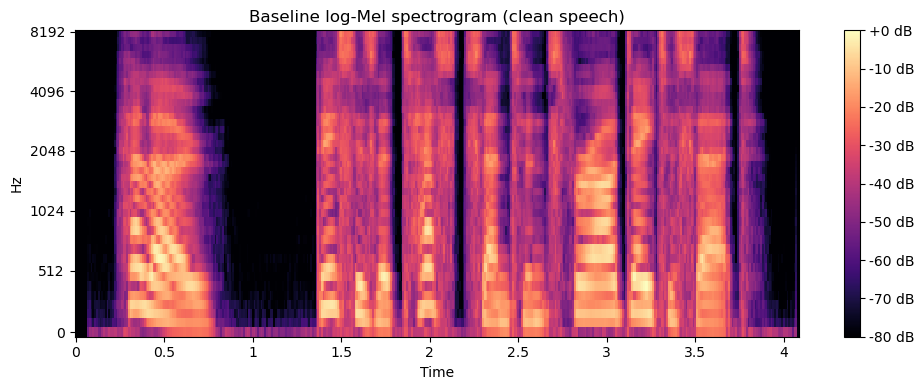

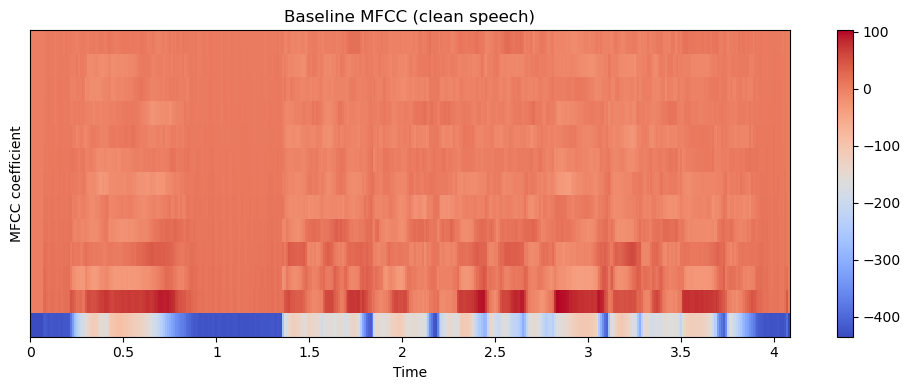

In [10]:
# ===============================
# Plot baseline log-Mel
# ===============================

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    logmel_clean,
    sr=sr,
    hop_length=160,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Baseline log-Mel spectrogram (clean speech)")
plt.tight_layout()
plt.show()


# ===============================
# Plot baseline MFCC
# ===============================

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    mfcc_clean,
    sr=sr,
    hop_length=160,
    x_axis="time"
)
plt.colorbar()
plt.title("Baseline MFCC (clean speech)")
plt.ylabel("MFCC coefficient")
plt.tight_layout()
plt.show()

## Optional check across multiple utterances

To make sure that the pipeline is working consistently, we can compute baseline features for several files.

In [11]:
# ===============================
# Optional: inspect several files
# ===============================

for file_path in audio_files[:3]:
    y_i, sr_i = librosa.load(file_path, sr=16000, mono=True)
    logmel_i = extract_logmel(y_i, sr=sr_i)
    mfcc_i = extract_mfcc(y_i, sr=sr_i)

    print(os.path.basename(file_path),
          "log-Mel shape:", logmel_i.shape,
          "MFCC shape:", mfcc_i.shape)

sample_0.wav log-Mel shape: (40, 409) MFCC shape: (13, 409)
sample_1.wav log-Mel shape: (40, 485) MFCC shape: (13, 485)
sample_2.wav log-Mel shape: (40, 517) MFCC shape: (13, 517)


# Task 2 — Noise Augmentation Experiment

In this task, we evaluate how additive noise affects speech features.

We start from the clean baseline signal and generate noisy speech at several SNR levels.

The procedure is:

1. prepare a noise signal
2. mix clean speech and noise at a target SNR
3. extract log-Mel and MFCC features
4. compare the noisy features with the clean baseline

We first implement utility functions for:

- RMS computation
- noise mixing with target SNR
- simple visualization of clean and noisy waveforms

In [12]:
# ===============================
# Task 2: utility functions
# ===============================

def rms(x):
    return np.sqrt(np.mean(np.square(x)) + 1e-12)


def match_length(x, target_len):
    """
    Repeat or crop a 1D signal so that its length matches target_len.
    """
    if len(x) == target_len:
        return x
    elif len(x) < target_len:
        n_repeat = int(np.ceil(target_len / len(x)))
        x = np.tile(x, n_repeat)
        return x[:target_len]
    else:
        return x[:target_len]


def mix_noise_at_snr(clean, noise, snr_db):
    """
    Mix clean speech with noise at a target SNR (in dB).

    SNR = 10 log10 (sum clean^2 / sum noise^2)
    """
    noise = match_length(noise, len(clean))

    clean_power = np.sum(clean ** 2) + 1e-12
    noise_power = np.sum(noise ** 2) + 1e-12

    target_noise_power = clean_power / (10 ** (snr_db / 10.0))
    scale = np.sqrt(target_noise_power / noise_power)

    noisy = clean + scale * noise

    # optional clipping protection
    max_abs = np.max(np.abs(noisy))
    if max_abs > 1.0:
        noisy = noisy / max_abs

    return noisy

## Prepare a noise signal

For a simple classroom experiment, we can start with synthetic white noise.

Later, this can be replaced by more realistic noise such as babble noise or environmental noise.

In [13]:
# ===============================
# Create synthetic white noise
# ===============================

rng = np.random.default_rng(1234)

white_noise = rng.normal(loc=0.0, scale=1.0, size=len(y))
white_noise = white_noise.astype(np.float32)

print("Noise length:", len(white_noise))
print("Noise RMS:", rms(white_noise))

Noise length: 65280
Noise RMS: 0.99917006


## Generate noisy speech at several SNR levels

In [14]:
# ===============================
# Generate noisy signals
# ===============================

snr_levels = [20, 10, 5, 0]

noisy_signals = {}

for snr_db in snr_levels:
    noisy_signals[snr_db] = mix_noise_at_snr(y, white_noise, snr_db)

print("Generated noisy signals for SNR levels:", snr_levels)

Generated noisy signals for SNR levels: [20, 10, 5, 0]


## Visualize clean and noisy waveforms

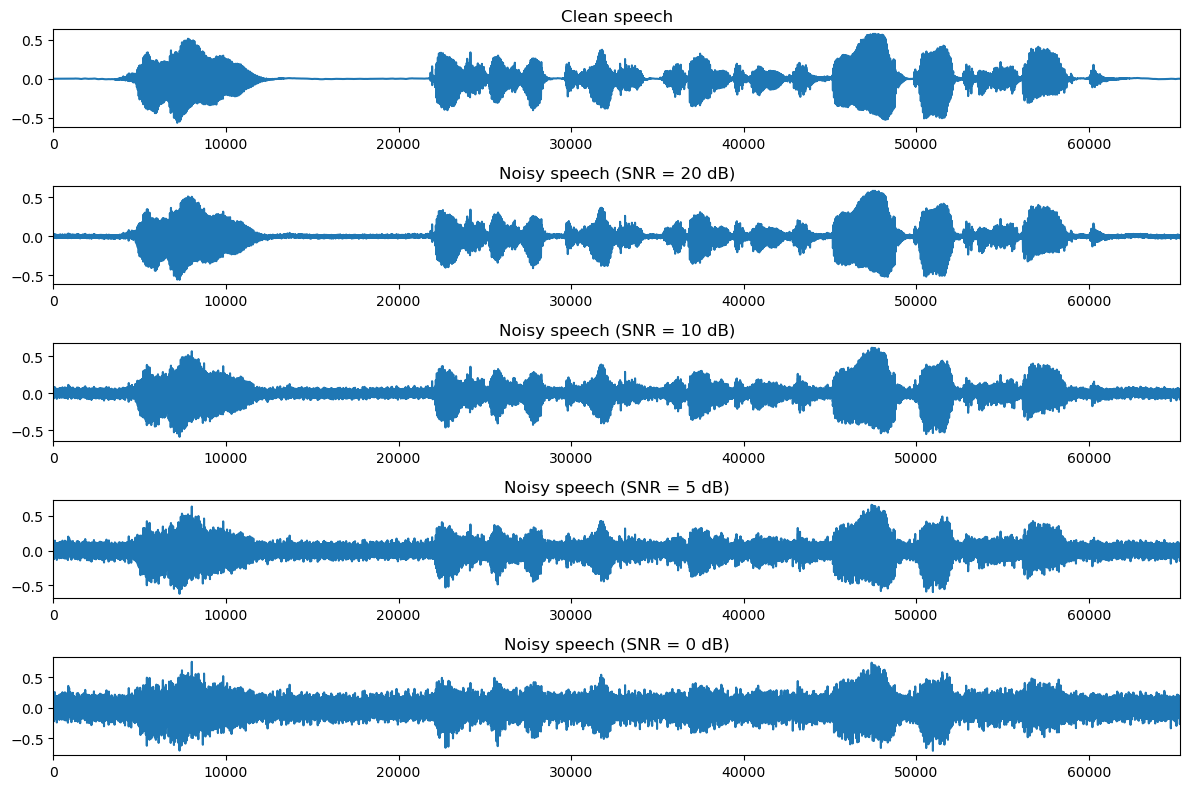

In [15]:
# ===============================
# Plot waveform comparison
# ===============================

plt.figure(figsize=(12, 8))

plt.subplot(5, 1, 1)
plt.plot(y)
plt.title("Clean speech")
plt.xlim(0, len(y))

for i, snr_db in enumerate(snr_levels, start=2):
    plt.subplot(5, 1, i)
    plt.plot(noisy_signals[snr_db])
    plt.title(f"Noisy speech (SNR = {snr_db} dB)")
    plt.xlim(0, len(y))

plt.tight_layout()
plt.show()

## Extract features from noisy speech

We now compute log-Mel spectrograms and MFCCs for each noisy signal.

In [16]:
# ===============================
# Extract noisy features
# ===============================

logmel_noisy = {}
mfcc_noisy = {}

for snr_db in snr_levels:
    y_noisy = noisy_signals[snr_db]
    logmel_noisy[snr_db] = extract_logmel(y_noisy, sr=sr)
    mfcc_noisy[snr_db] = extract_mfcc(y_noisy, sr=sr)

for snr_db in snr_levels:
    print(
        f"SNR={snr_db} dB",
        "log-Mel shape:", logmel_noisy[snr_db].shape,
        "MFCC shape:", mfcc_noisy[snr_db].shape
    )

SNR=20 dB log-Mel shape: (40, 409) MFCC shape: (13, 409)
SNR=10 dB log-Mel shape: (40, 409) MFCC shape: (13, 409)
SNR=5 dB log-Mel shape: (40, 409) MFCC shape: (13, 409)
SNR=0 dB log-Mel shape: (40, 409) MFCC shape: (13, 409)


## Visualize log-Mel spectrograms under noise

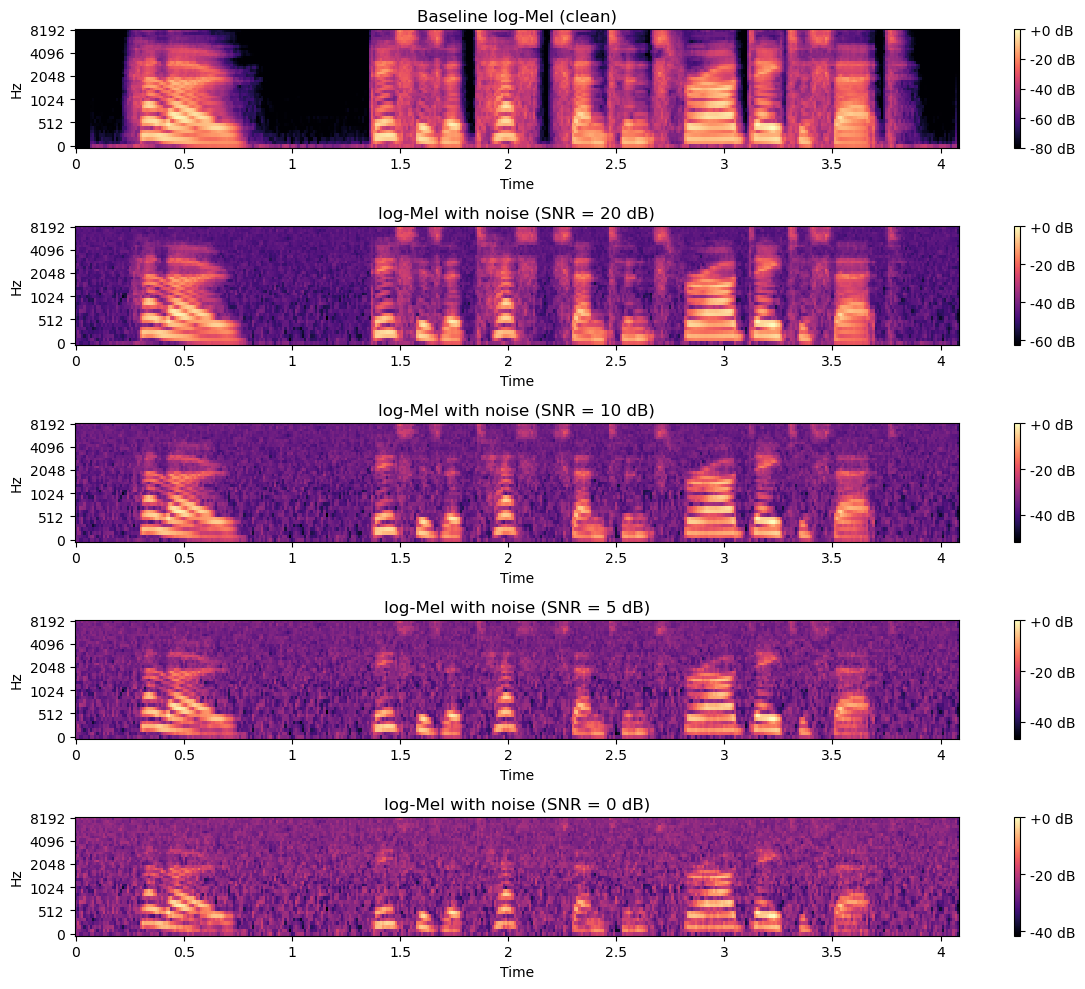

In [17]:
# ===============================
# Plot log-Mel spectrograms
# ===============================

plt.figure(figsize=(12, 10))

plt.subplot(5, 1, 1)
librosa.display.specshow(
    logmel_clean,
    sr=sr,
    hop_length=160,
    x_axis="time",
    y_axis="mel"
)
plt.title("Baseline log-Mel (clean)")
plt.colorbar(format="%+2.0f dB")

for i, snr_db in enumerate(snr_levels, start=2):
    plt.subplot(5, 1, i)
    librosa.display.specshow(
        logmel_noisy[snr_db],
        sr=sr,
        hop_length=160,
        x_axis="time",
        y_axis="mel"
    )
    plt.title(f"log-Mel with noise (SNR = {snr_db} dB)")
    plt.colorbar(format="%+2.0f dB")

plt.tight_layout()
plt.show()

## Visualize MFCCs under noise

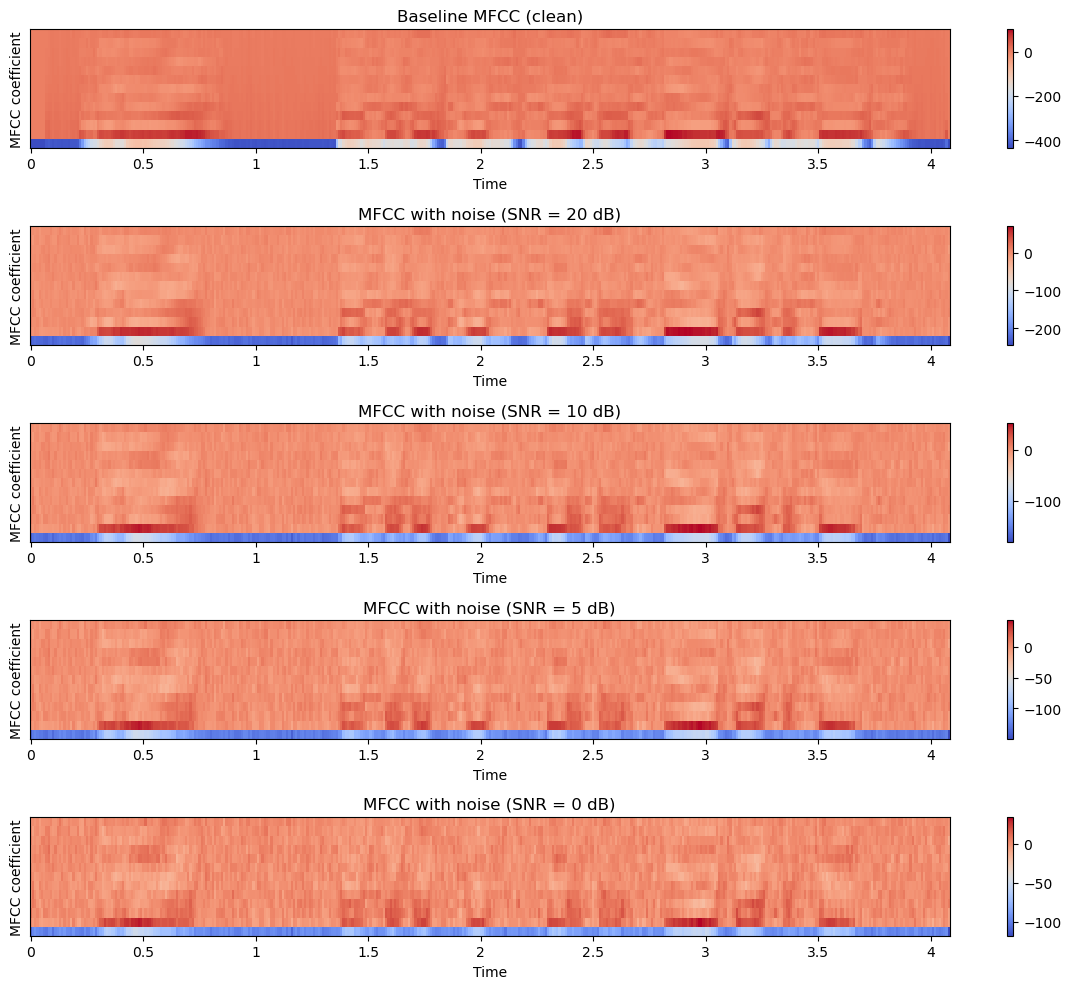

In [18]:
# ===============================
# Plot MFCCs
# ===============================

plt.figure(figsize=(12, 10))

plt.subplot(5, 1, 1)
librosa.display.specshow(
    mfcc_clean,
    sr=sr,
    hop_length=160,
    x_axis="time"
)
plt.title("Baseline MFCC (clean)")
plt.ylabel("MFCC coefficient")
plt.colorbar()

for i, snr_db in enumerate(snr_levels, start=2):
    plt.subplot(5, 1, i)
    librosa.display.specshow(
        mfcc_noisy[snr_db],
        sr=sr,
        hop_length=160,
        x_axis="time"
    )
    plt.title(f"MFCC with noise (SNR = {snr_db} dB)")
    plt.ylabel("MFCC coefficient")
    plt.colorbar()

plt.tight_layout()
plt.show()

## Compare noisy features with the clean baseline

To quantify robustness, we compare the noisy features with the clean baseline using:

- Pearson correlation
- Spearman correlation
- Mean squared error (MSE)
- Cosine similarity

For simplicity, we first flatten each feature matrix into a vector.

In [19]:
# ===============================
# Metric functions
# ===============================

def flatten_pair(a, b):
    """
    Align two feature matrices by truncating to the same number of frames,
    then flatten them into 1D vectors.
    """
    n_frames = min(a.shape[1], b.shape[1])
    a_aligned = a[:, :n_frames]
    b_aligned = b[:, :n_frames]
    return a_aligned.flatten(), b_aligned.flatten()


def compute_metrics(ref, test):
    x, y_vec = flatten_pair(ref, test)

    r, _ = pearsonr(x, y_vec)
    rho, _ = spearmanr(x, y_vec)
    mse = mean_squared_error(x, y_vec)
    cos = cosine_similarity(x.reshape(1, -1), y_vec.reshape(1, -1))[0, 0]

    return {
        "pearson_r": r,
        "spearman_rho": rho,
        "mse": mse,
        "cosine_similarity": cos
    }

## Evaluate log-Mel robustness under noise

In [20]:
# ===============================
# Evaluate log-Mel
# ===============================

results_logmel_noise = {}

for snr_db in snr_levels:
    results_logmel_noise[snr_db] = compute_metrics(
        logmel_clean,
        logmel_noisy[snr_db]
    )

results_logmel_noise

{20: {'pearson_r': np.float32(0.8532315),
  'spearman_rho': np.float64(0.9045182271865041),
  'mse': 318.72406005859375,
  'cosine_similarity': np.float32(0.97344106)},
 10: {'pearson_r': np.float32(0.71037364),
  'spearman_rho': np.float64(0.7149529405103441),
  'mse': 594.6754760742188,
  'cosine_similarity': np.float32(0.95570356)},
 5: {'pearson_r': np.float32(0.6178164),
  'spearman_rho': np.float64(0.5705783842234727),
  'mse': 782.764892578125,
  'cosine_similarity': np.float32(0.94661415)},
 0: {'pearson_r': np.float32(0.51172185),
  'spearman_rho': np.float64(0.43032193961915427),
  'mse': 1003.9183349609375,
  'cosine_similarity': np.float32(0.937764)}}

## Evaluate MFCC robustness under noise

In [21]:
# ===============================
# Evaluate MFCC
# ===============================

results_mfcc_noise = {}

for snr_db in snr_levels:
    results_mfcc_noise[snr_db] = compute_metrics(
        mfcc_clean,
        mfcc_noisy[snr_db]
    )

results_mfcc_noise

{20: {'pearson_r': np.float32(0.96368825),
  'spearman_rho': np.float64(0.8082407682881914),
  'mse': 963.3462524414062,
  'cosine_similarity': np.float32(0.9642154)},
 10: {'pearson_r': np.float32(0.9382167),
  'spearman_rho': np.float64(0.687043790195308),
  'mse': 1783.9932861328125,
  'cosine_similarity': np.float32(0.93930215)},
 5: {'pearson_r': np.float32(0.92488784),
  'spearman_rho': np.float64(0.6120150035912595),
  'mse': 2340.1494140625,
  'cosine_similarity': np.float32(0.9263523)},
 0: {'pearson_r': np.float32(0.91133475),
  'spearman_rho': np.float64(0.5338105126261943),
  'mse': 3013.98876953125,
  'cosine_similarity': np.float32(0.9132403)}}

## Print results in a readable form

In [22]:
# ===============================
# Print results
# ===============================

print("=== log-Mel robustness under noise ===")
for snr_db in snr_levels:
    print(f"SNR = {snr_db} dB:", results_logmel_noise[snr_db])

print("\n=== MFCC robustness under noise ===")
for snr_db in snr_levels:
    print(f"SNR = {snr_db} dB:", results_mfcc_noise[snr_db])

=== log-Mel robustness under noise ===
SNR = 20 dB: {'pearson_r': np.float32(0.8532315), 'spearman_rho': np.float64(0.9045182271865041), 'mse': 318.72406005859375, 'cosine_similarity': np.float32(0.97344106)}
SNR = 10 dB: {'pearson_r': np.float32(0.71037364), 'spearman_rho': np.float64(0.7149529405103441), 'mse': 594.6754760742188, 'cosine_similarity': np.float32(0.95570356)}
SNR = 5 dB: {'pearson_r': np.float32(0.6178164), 'spearman_rho': np.float64(0.5705783842234727), 'mse': 782.764892578125, 'cosine_similarity': np.float32(0.94661415)}
SNR = 0 dB: {'pearson_r': np.float32(0.51172185), 'spearman_rho': np.float64(0.43032193961915427), 'mse': 1003.9183349609375, 'cosine_similarity': np.float32(0.937764)}

=== MFCC robustness under noise ===
SNR = 20 dB: {'pearson_r': np.float32(0.96368825), 'spearman_rho': np.float64(0.8082407682881914), 'mse': 963.3462524414062, 'cosine_similarity': np.float32(0.9642154)}
SNR = 10 dB: {'pearson_r': np.float32(0.9382167), 'spearman_rho': np.float64(0.

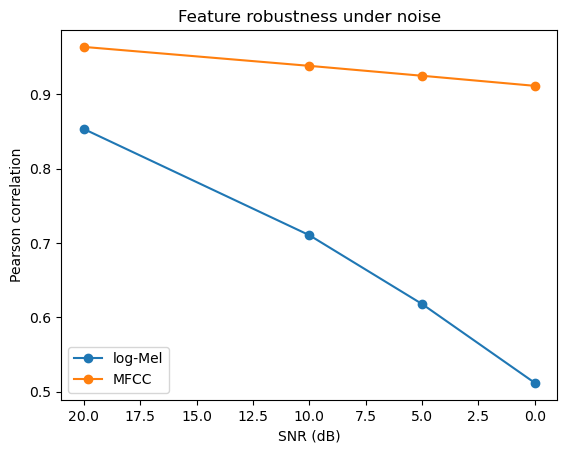

In [23]:
snr = [20,10,5,0]

logmel_r = [results_logmel_noise[s]["pearson_r"] for s in snr]
mfcc_r = [results_mfcc_noise[s]["pearson_r"] for s in snr]

plt.plot(snr, logmel_r, marker="o", label="log-Mel")
plt.plot(snr, mfcc_r, marker="o", label="MFCC")

plt.xlabel("SNR (dB)")
plt.ylabel("Pearson correlation")
plt.title("Feature robustness under noise")

plt.legend()
plt.gca().invert_xaxis()
plt.show()

# Task 3 — Reverberation Experiment

In this task, we evaluate how reverberation affects speech features.

Reverberation is modeled by convolution with a room impulse response (RIR):

x'[t] = (x * h)[t]

where:

- x[t] is the clean speech signal
- h[t] is the room impulse response
- x'[t] is the reverberant speech signal

We will:

1. generate simple synthetic RIRs
2. apply reverberation by convolution
3. extract log-Mel and MFCC features
4. compare reverberant features with the clean baseline

In [24]:
# ===============================
# Task 3: utility functions for reverberation
# ===============================

from scipy.signal import fftconvolve

## Create a simple synthetic room impulse response (RIR)

For a simple classroom experiment, we approximate reverberation using:

- one direct path
- a few early reflections
- an exponentially decaying late tail

The decay rate is controlled by a parameter related to RT60.

In [25]:
# ===============================
# Synthetic RIR generator
# ===============================

def generate_synthetic_rir(
    rt60,
    sr=16000,
    duration=2.0,
    direct_gain=1.0,
    early_reflection_gains=(0.5, 0.35, 0.25),
    early_reflection_delays=(0.01, 0.02, 0.035),
    seed=1234
):
    """
    Generate a simple synthetic RIR with:
    - direct path
    - early reflections
    - exponentially decaying late reverberation tail

    rt60: reverberation time in seconds
    """
    rng = np.random.default_rng(seed)

    n = int(duration * sr)
    t = np.arange(n) / sr

    h = np.zeros(n, dtype=np.float32)

    # direct path
    h[0] = direct_gain

    # early reflections
    for gain, delay in zip(early_reflection_gains, early_reflection_delays):
        idx = int(delay * sr)
        if idx < n:
            h[idx] += gain

    # exponential late tail
    # Energy decay model: E(t) = E_0 exp(-t / tau)
    # Approximate relation: RT60 ≈ 13.82 * tau
    tau = rt60 / 13.82
    decay = np.exp(-t / tau)

    # random late reverberation texture
    late_noise = rng.normal(0.0, 1.0, size=n).astype(np.float32)
    late_tail = 0.05 * decay * late_noise

    # start late tail slightly after the direct path
    start_idx = int(0.03 * sr)
    if start_idx < n:
        h[start_idx:] += late_tail[start_idx:]

    # normalize
    h = h / (np.max(np.abs(h)) + 1e-12)

    return h

## Visualize synthetic RIRs for several RT60 values

In [26]:
# ===============================
# Generate example RIRs
# ===============================

rt60_levels = [0.2, 0.8, 2.0]

rir_dict = {}

for rt60 in rt60_levels:
    rir_dict[rt60] = generate_synthetic_rir(rt60=rt60, sr=sr, duration=2.0, seed=1234)

print("Generated RIRs for RT60 values:", rt60_levels)

Generated RIRs for RT60 values: [0.2, 0.8, 2.0]


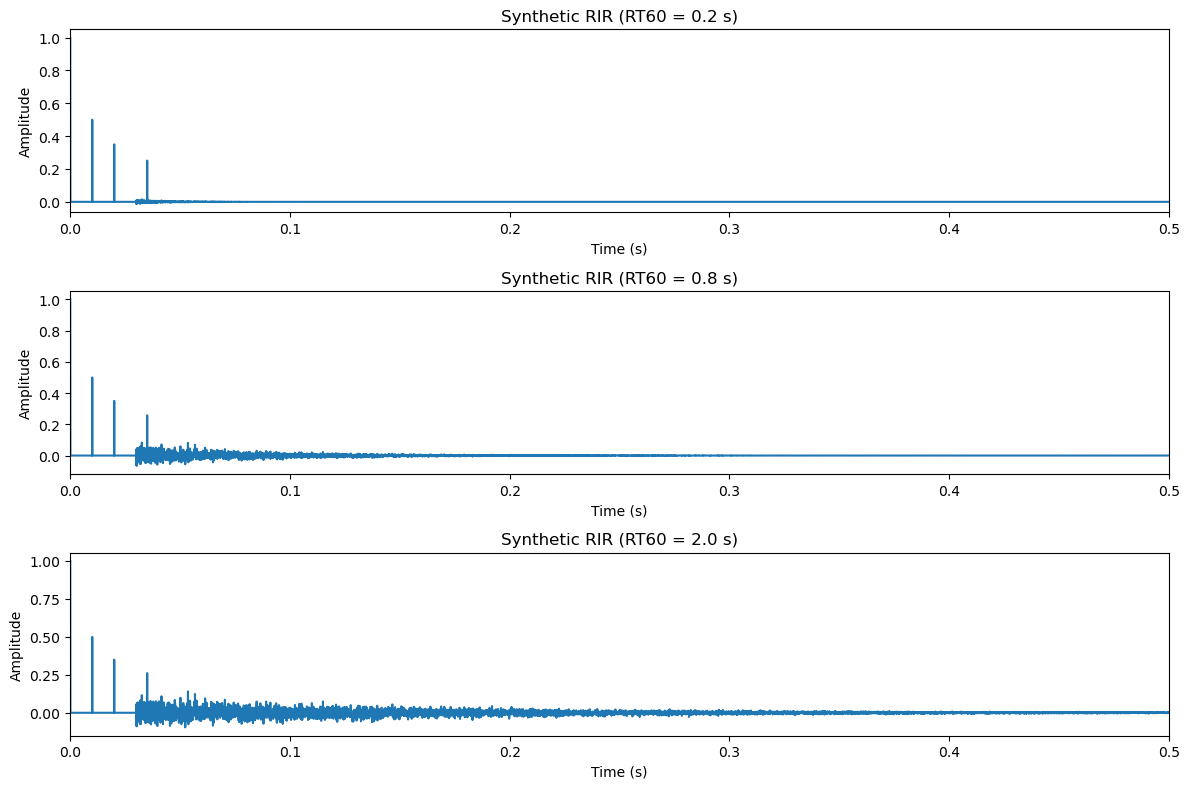

In [27]:
# ===============================
# Plot RIRs
# ===============================

plt.figure(figsize=(12, 8))

for i, rt60 in enumerate(rt60_levels, start=1):
    h = rir_dict[rt60]
    t_h = np.arange(len(h)) / sr

    plt.subplot(len(rt60_levels), 1, i)
    plt.plot(t_h, h)
    plt.title(f"Synthetic RIR (RT60 = {rt60} s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.xlim(0, 0.5)

plt.tight_layout()
plt.show()

## Apply reverberation to the clean speech signal

We use convolution:
$$
(x * h)[t] = \sum_{\tau} x[\tau] h[t-\tau]
$$
For feature comparison, we trim the convolved output to the original signal length.

In [28]:
# ===============================
# Reverberation function
# ===============================

def apply_reverb(clean, rir):
    """
    Apply reverberation by convolution and trim to original length.
    """
    y_reverb = fftconvolve(clean, rir, mode="full")
    y_reverb = y_reverb[:len(clean)]

    # normalize only if needed
    max_abs = np.max(np.abs(y_reverb))
    if max_abs > 1.0:
        y_reverb = y_reverb / max_abs

    return y_reverb.astype(np.float32)

## Generate reverberant signals for several RT60 values

In [29]:
# ===============================
# Generate reverberant signals
# ===============================

reverb_signals = {}

for rt60 in rt60_levels:
    reverb_signals[rt60] = apply_reverb(y, rir_dict[rt60])

print("Generated reverberant signals for RT60 values:", rt60_levels)

Generated reverberant signals for RT60 values: [0.2, 0.8, 2.0]


## Visualize clean and reverberant waveforms

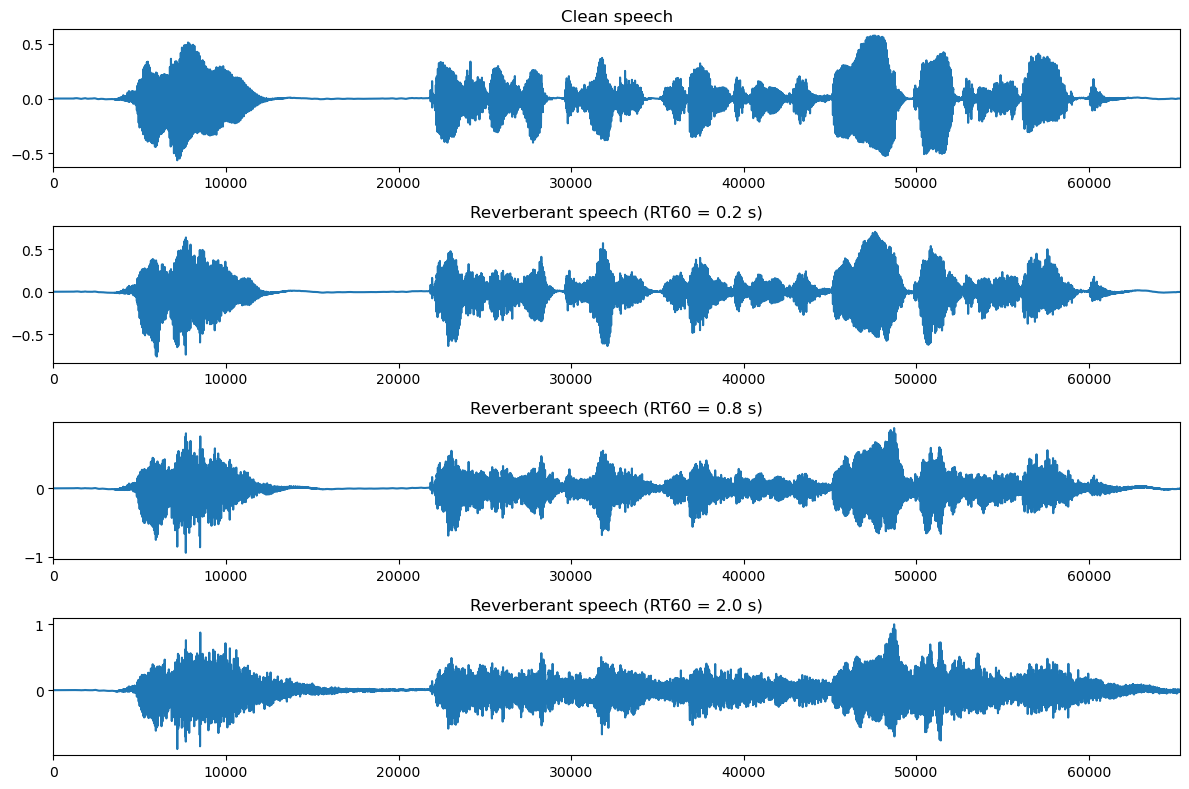

In [30]:
# ===============================
# Plot waveform comparison
# ===============================

plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(y)
plt.title("Clean speech")
plt.xlim(0, len(y))

for i, rt60 in enumerate(rt60_levels, start=2):
    plt.subplot(4, 1, i)
    plt.plot(reverb_signals[rt60])
    plt.title(f"Reverberant speech (RT60 = {rt60} s)")
    plt.xlim(0, len(y))

plt.tight_layout()
plt.show()

## Extract features from reverberant speech

We now compute log-Mel spectrograms and MFCCs for each reverberant signal.

In [31]:
# ===============================
# Extract reverberant features
# ===============================

logmel_reverb = {}
mfcc_reverb = {}

for rt60 in rt60_levels:
    y_rev = reverb_signals[rt60]
    logmel_reverb[rt60] = extract_logmel(y_rev, sr=sr)
    mfcc_reverb[rt60] = extract_mfcc(y_rev, sr=sr)

for rt60 in rt60_levels:
    print(
        f"RT60={rt60} s",
        "log-Mel shape:", logmel_reverb[rt60].shape,
        "MFCC shape:", mfcc_reverb[rt60].shape
    )

RT60=0.2 s log-Mel shape: (40, 409) MFCC shape: (13, 409)
RT60=0.8 s log-Mel shape: (40, 409) MFCC shape: (13, 409)
RT60=2.0 s log-Mel shape: (40, 409) MFCC shape: (13, 409)


## Visualize log-Mel spectrograms under reverberation

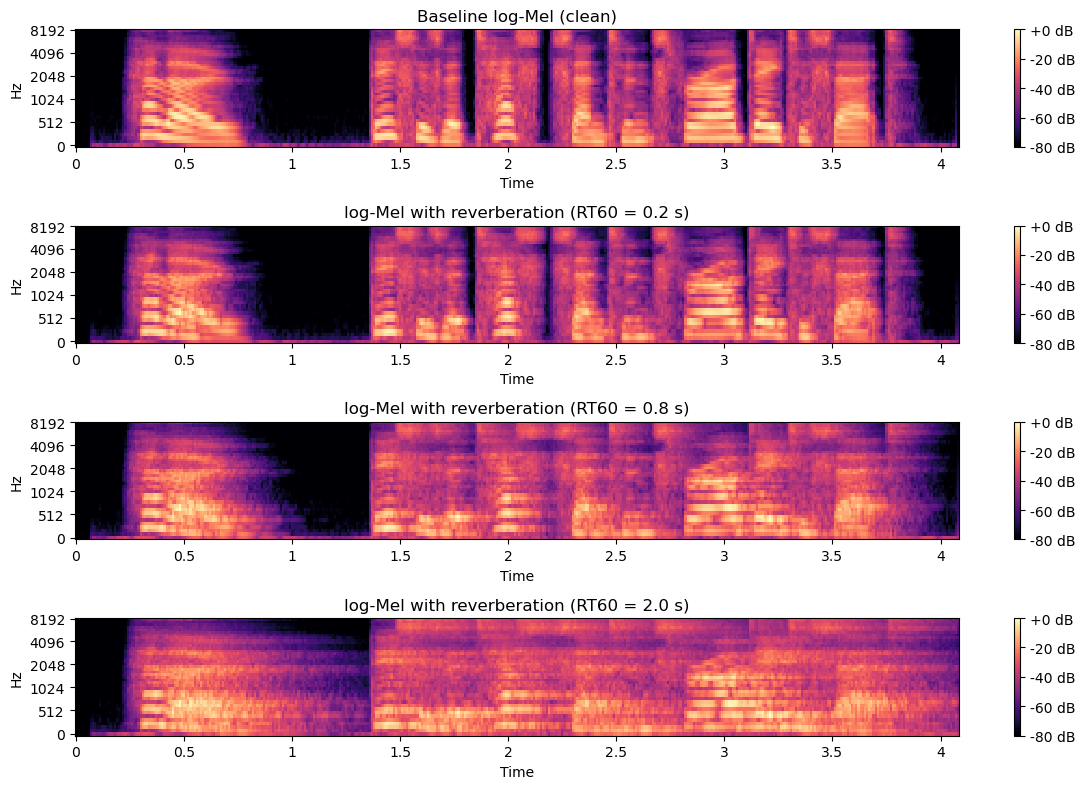

In [32]:
# ===============================
# Plot log-Mel spectrograms
# ===============================

plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
librosa.display.specshow(
    logmel_clean,
    sr=sr,
    hop_length=160,
    x_axis="time",
    y_axis="mel"
)
plt.title("Baseline log-Mel (clean)")
plt.colorbar(format="%+2.0f dB")

for i, rt60 in enumerate(rt60_levels, start=2):
    plt.subplot(4, 1, i)
    librosa.display.specshow(
        logmel_reverb[rt60],
        sr=sr,
        hop_length=160,
        x_axis="time",
        y_axis="mel"
    )
    plt.title(f"log-Mel with reverberation (RT60 = {rt60} s)")
    plt.colorbar(format="%+2.0f dB")

plt.tight_layout()
plt.show()

## Visualize MFCCs under reverberation

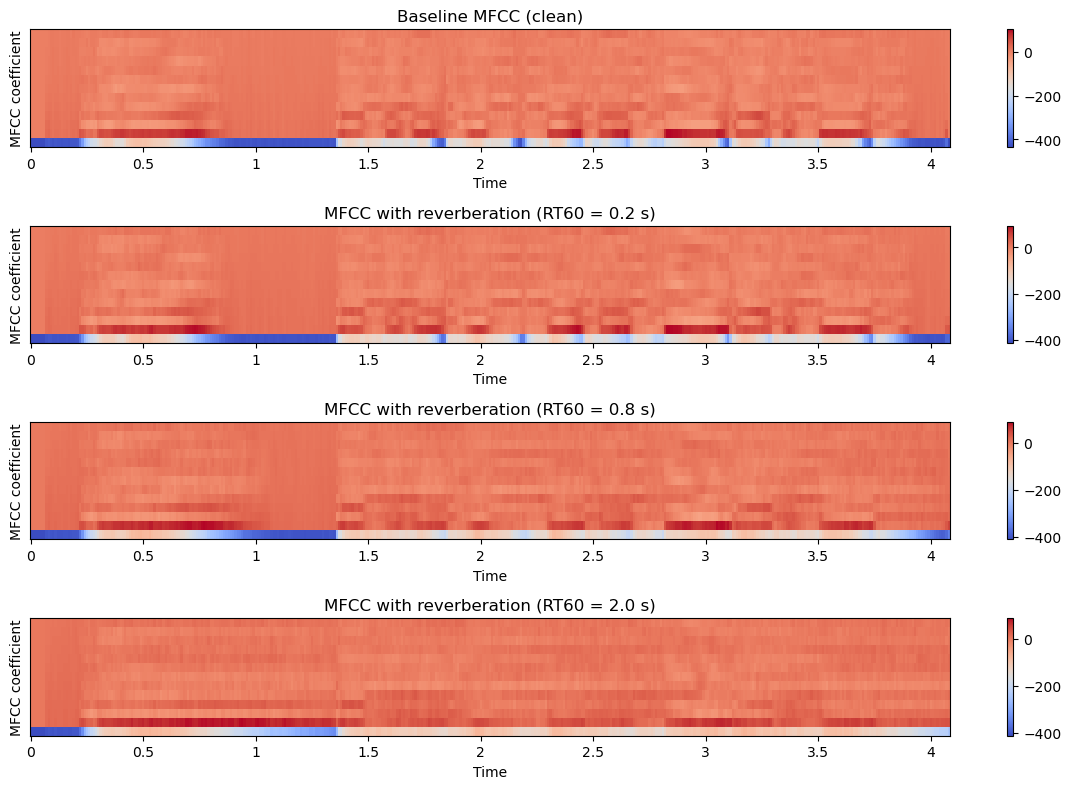

In [33]:
# ===============================
# Plot MFCCs
# ===============================

plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
librosa.display.specshow(
    mfcc_clean,
    sr=sr,
    hop_length=160,
    x_axis="time"
)
plt.title("Baseline MFCC (clean)")
plt.ylabel("MFCC coefficient")
plt.colorbar()

for i, rt60 in enumerate(rt60_levels, start=2):
    plt.subplot(4, 1, i)
    librosa.display.specshow(
        mfcc_reverb[rt60],
        sr=sr,
        hop_length=160,
        x_axis="time"
    )
    plt.title(f"MFCC with reverberation (RT60 = {rt60} s)")
    plt.ylabel("MFCC coefficient")
    plt.colorbar()

plt.tight_layout()
plt.show()

## Compare reverberant features with the clean baseline

We reuse the same evaluation metrics as in Task 2:

- Pearson correlation
- Spearman correlation
- Mean squared error (MSE)
- Cosine similarity

In [34]:
# ===============================
# Evaluate log-Mel under reverberation
# ===============================

results_logmel_reverb = {}

for rt60 in rt60_levels:
    results_logmel_reverb[rt60] = compute_metrics(
        logmel_clean,
        logmel_reverb[rt60]
    )

results_logmel_reverb

{0.2: {'pearson_r': np.float32(0.97612715),
  'spearman_rho': np.float64(0.9745119310241581),
  'mse': 22.27591896057129,
  'cosine_similarity': np.float32(0.9961569)},
 0.8: {'pearson_r': np.float32(0.90389323),
  'spearman_rho': np.float64(0.9064354561704807),
  'mse': 100.63221740722656,
  'cosine_similarity': np.float32(0.984626)},
 2.0: {'pearson_r': np.float32(0.7381401),
  'spearman_rho': np.float64(0.7529399108024382),
  'mse': 322.6571350097656,
  'cosine_similarity': np.float32(0.95846176)}}

## Evaluate MFCC under reverberation

In [35]:
# ===============================
# Evaluate MFCC under reverberation
# ===============================

results_mfcc_reverb = {}

for rt60 in rt60_levels:
    results_mfcc_reverb[rt60] = compute_metrics(
        mfcc_clean,
        mfcc_reverb[rt60]
    )

results_mfcc_reverb

{0.2: {'pearson_r': np.float32(0.9946071),
  'spearman_rho': np.float64(0.9351420066621379),
  'mse': 87.46570587158203,
  'cosine_similarity': np.float32(0.9947823)},
 0.8: {'pearson_r': np.float32(0.9739588),
  'spearman_rho': np.float64(0.8094850791946696),
  'mse': 419.2286682128906,
  'cosine_similarity': np.float32(0.97479004)},
 2.0: {'pearson_r': np.float32(0.9244831),
  'spearman_rho': np.float64(0.6234824747824422),
  'mse': 1219.8402099609375,
  'cosine_similarity': np.float32(0.9269243)}}

## Print reverberation results

In [36]:
# ===============================
# Print results
# ===============================

print("=== log-Mel robustness under reverberation ===")
for rt60 in rt60_levels:
    print(f"RT60 = {rt60} s:", results_logmel_reverb[rt60])

print("\n=== MFCC robustness under reverberation ===")
for rt60 in rt60_levels:
    print(f"RT60 = {rt60} s:", results_mfcc_reverb[rt60])

=== log-Mel robustness under reverberation ===
RT60 = 0.2 s: {'pearson_r': np.float32(0.97612715), 'spearman_rho': np.float64(0.9745119310241581), 'mse': 22.27591896057129, 'cosine_similarity': np.float32(0.9961569)}
RT60 = 0.8 s: {'pearson_r': np.float32(0.90389323), 'spearman_rho': np.float64(0.9064354561704807), 'mse': 100.63221740722656, 'cosine_similarity': np.float32(0.984626)}
RT60 = 2.0 s: {'pearson_r': np.float32(0.7381401), 'spearman_rho': np.float64(0.7529399108024382), 'mse': 322.6571350097656, 'cosine_similarity': np.float32(0.95846176)}

=== MFCC robustness under reverberation ===
RT60 = 0.2 s: {'pearson_r': np.float32(0.9946071), 'spearman_rho': np.float64(0.9351420066621379), 'mse': 87.46570587158203, 'cosine_similarity': np.float32(0.9947823)}
RT60 = 0.8 s: {'pearson_r': np.float32(0.9739588), 'spearman_rho': np.float64(0.8094850791946696), 'mse': 419.2286682128906, 'cosine_similarity': np.float32(0.97479004)}
RT60 = 2.0 s: {'pearson_r': np.float32(0.9244831), 'spearma

## Plot Pearson correlation versus RT60

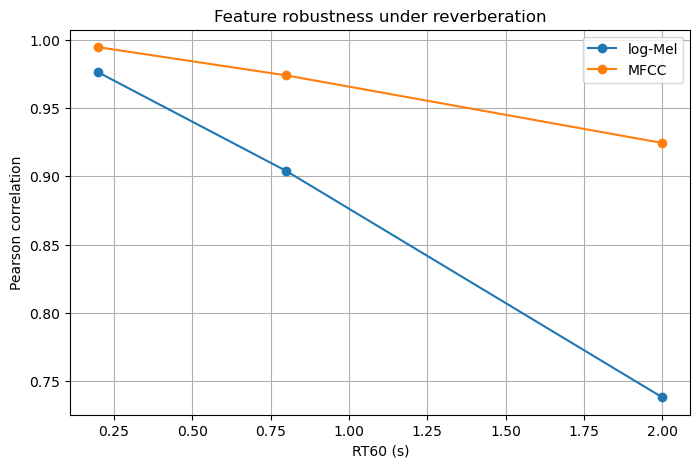

In [37]:
# ===============================
# Plot Pearson correlation
# ===============================

rt60_plot = rt60_levels

logmel_r_reverb = [results_logmel_reverb[r]["pearson_r"] for r in rt60_plot]
mfcc_r_reverb = [results_mfcc_reverb[r]["pearson_r"] for r in rt60_plot]

plt.figure(figsize=(8, 5))
plt.plot(rt60_plot, logmel_r_reverb, marker="o", label="log-Mel")
plt.plot(rt60_plot, mfcc_r_reverb, marker="o", label="MFCC")

plt.xlabel("RT60 (s)")
plt.ylabel("Pearson correlation")
plt.title("Feature robustness under reverberation")
plt.legend()
plt.grid(True)
plt.show()

## Interpretation

As RT60 increases, reverberation becomes stronger.

We expect:

- temporal smearing to increase
- similarity to the clean baseline to decrease
- MSE to increase

This experiment helps us understand how robust log-Mel and MFCC features are to room acoustics.

# Task 4 — Combined Noise and Reverberation

In this task, we evaluate speech features under combined acoustic distortions.

We apply:

1. reverberation using a room impulse response
2. additive noise at a target SNR

The model is:
$$
x'[t] = (x * h)[t] + \alpha n[t]
$$
where:

- $x[t]$ is the clean speech signal
- $h[t]$ is the room impulse response
- $n[t]$ is the noise signal
- $\alpha$ controls the noise level

This simulates more realistic acoustic conditions than noise-only or reverberation-only experiments.

## Define representative acoustic conditions

To keep the notebook compact and interpretable, we use a small set of representative SNR–RT60 pairs.

In [38]:
# ===============================
# Task 4: representative conditions
# ===============================

combined_conditions = [
    (20, 0.2),
    (10, 0.8),
    (5, 0.8),
    (0, 2.0),
]

print("Combined conditions (SNR, RT60):")
for cond in combined_conditions:
    print(cond)

Combined conditions (SNR, RT60):
(20, 0.2)
(10, 0.8)
(5, 0.8)
(0, 2.0)


## Generate noisy reverberant speech

We first apply reverberation and then add noise.

In [39]:
# ===============================
# Generate combined distorted signals
# ===============================

combined_signals = {}

for snr_db, rt60 in combined_conditions:
    # Step 1: reverberation
    y_reverb = apply_reverb(y, rir_dict[rt60])

    # Step 2: additive noise at target SNR
    y_combined = mix_noise_at_snr(y_reverb, white_noise, snr_db)

    combined_signals[(snr_db, rt60)] = y_combined

print("Generated combined distorted signals.")

Generated combined distorted signals.


## Visualize clean and combined distorted waveforms

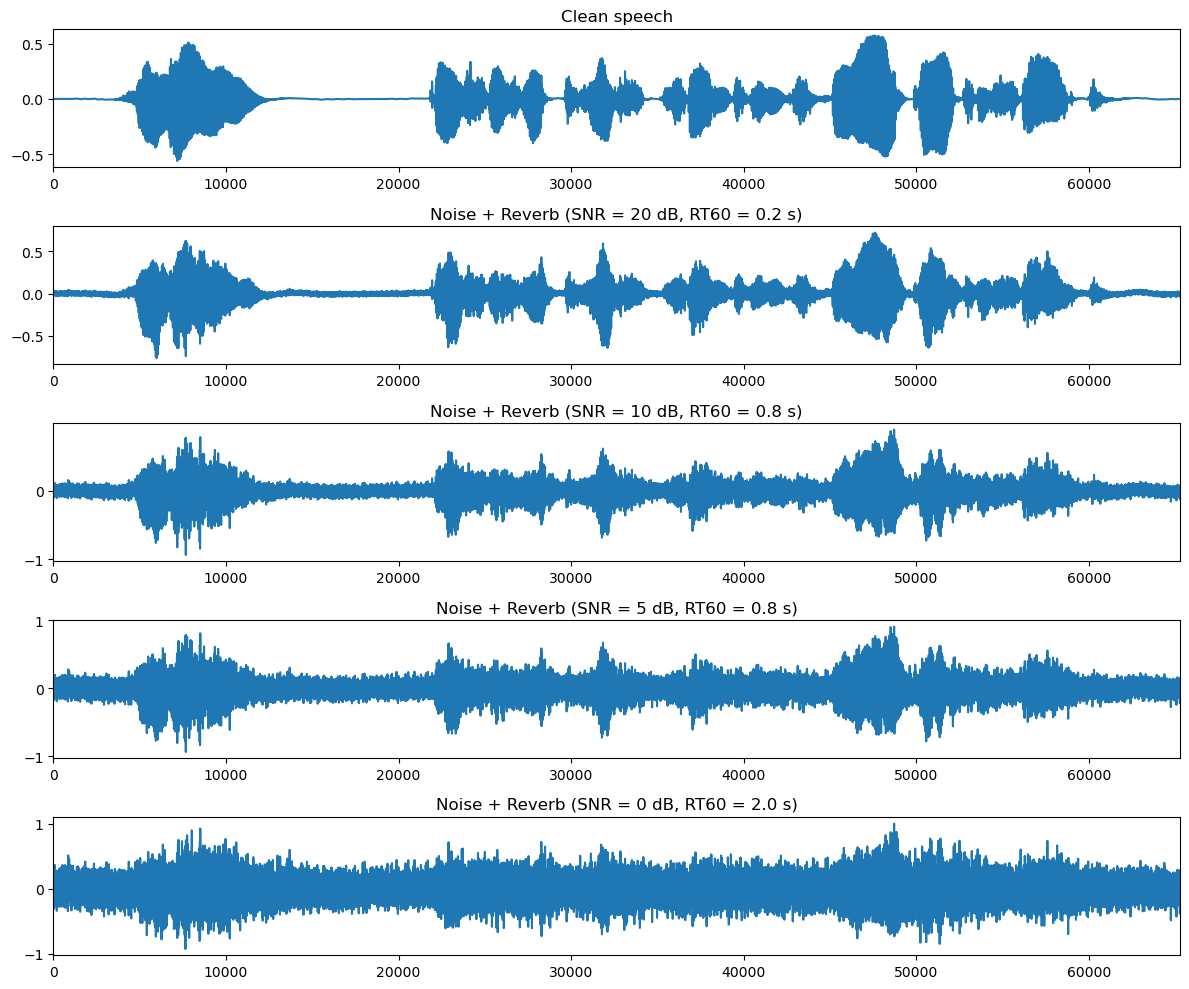

In [40]:
# ===============================
# Plot waveform comparison
# ===============================

plt.figure(figsize=(12, 10))

plt.subplot(len(combined_conditions) + 1, 1, 1)
plt.plot(y)
plt.title("Clean speech")
plt.xlim(0, len(y))

for i, (snr_db, rt60) in enumerate(combined_conditions, start=2):
    plt.subplot(len(combined_conditions) + 1, 1, i)
    plt.plot(combined_signals[(snr_db, rt60)])
    plt.title(f"Noise + Reverb (SNR = {snr_db} dB, RT60 = {rt60} s)")
    plt.xlim(0, len(y))

plt.tight_layout()
plt.show()

## Extract features from noisy reverberant speech

In [41]:
# ===============================
# Extract combined features
# ===============================

logmel_combined = {}
mfcc_combined = {}

for snr_db, rt60 in combined_conditions:
    y_combined = combined_signals[(snr_db, rt60)]
    logmel_combined[(snr_db, rt60)] = extract_logmel(y_combined, sr=sr)
    mfcc_combined[(snr_db, rt60)] = extract_mfcc(y_combined, sr=sr)

for snr_db, rt60 in combined_conditions:
    print(
        f"(SNR={snr_db} dB, RT60={rt60} s)",
        "log-Mel shape:", logmel_combined[(snr_db, rt60)].shape,
        "MFCC shape:", mfcc_combined[(snr_db, rt60)].shape
    )

(SNR=20 dB, RT60=0.2 s) log-Mel shape: (40, 409) MFCC shape: (13, 409)
(SNR=10 dB, RT60=0.8 s) log-Mel shape: (40, 409) MFCC shape: (13, 409)
(SNR=5 dB, RT60=0.8 s) log-Mel shape: (40, 409) MFCC shape: (13, 409)
(SNR=0 dB, RT60=2.0 s) log-Mel shape: (40, 409) MFCC shape: (13, 409)


## Visualize log-Mel spectrograms under combined distortions

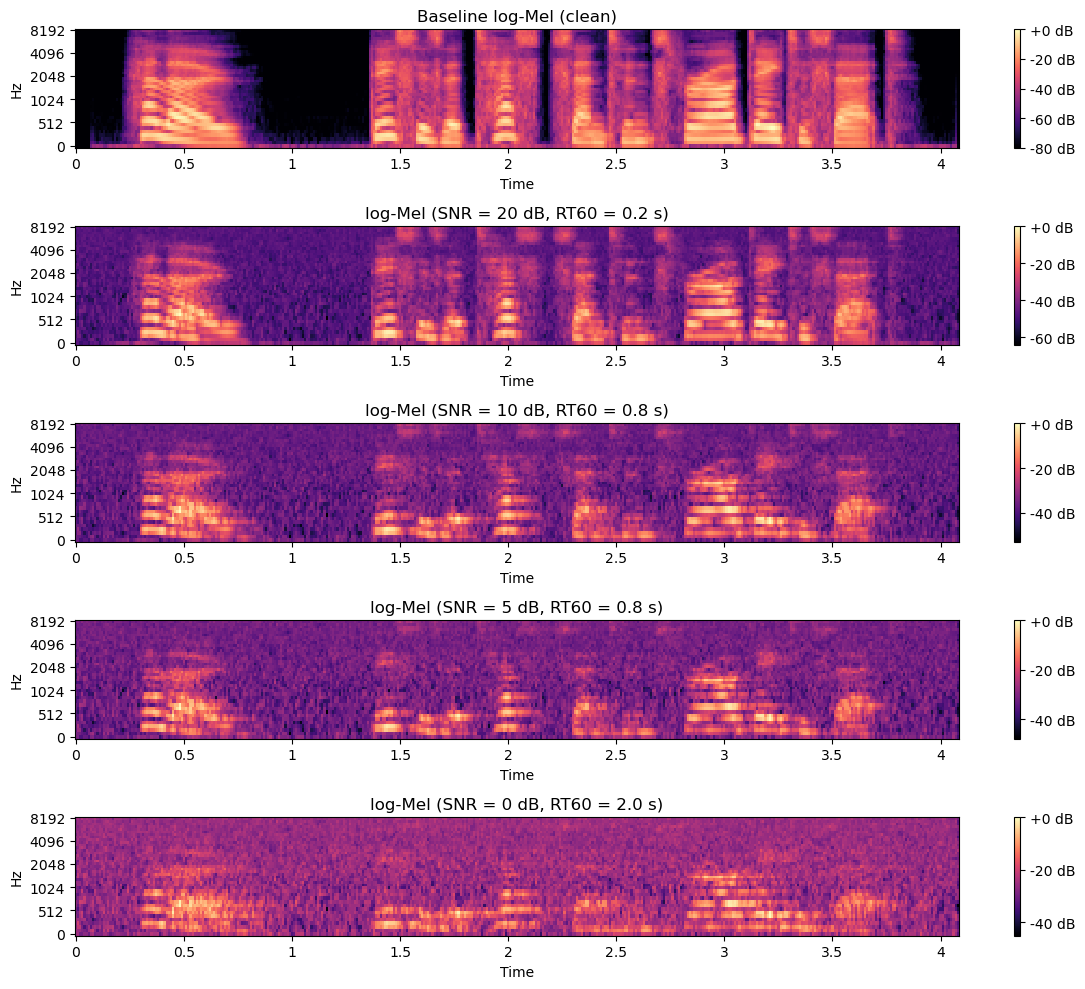

In [43]:
# ===============================
# Plot log-Mel spectrograms
# ===============================

plt.figure(figsize=(12, 10))

plt.subplot(len(combined_conditions) + 1, 1, 1)
librosa.display.specshow(
    logmel_clean,
    sr=sr,
    hop_length=160,
    x_axis="time",
    y_axis="mel"
)
plt.title("Baseline log-Mel (clean)")
plt.colorbar(format="%+2.0f dB")

for i, (snr_db, rt60) in enumerate(combined_conditions, start=2):
    plt.subplot(len(combined_conditions) + 1, 1, i)
    librosa.display.specshow(
        logmel_combined[(snr_db, rt60)],
        sr=sr,
        hop_length=160,
        x_axis="time",
        y_axis="mel"
    )
    plt.title(f"log-Mel (SNR = {snr_db} dB, RT60 = {rt60} s)")
    plt.colorbar(format="%+2.0f dB")

plt.tight_layout()
plt.show()

## Visualize MFCCs under combined distortions

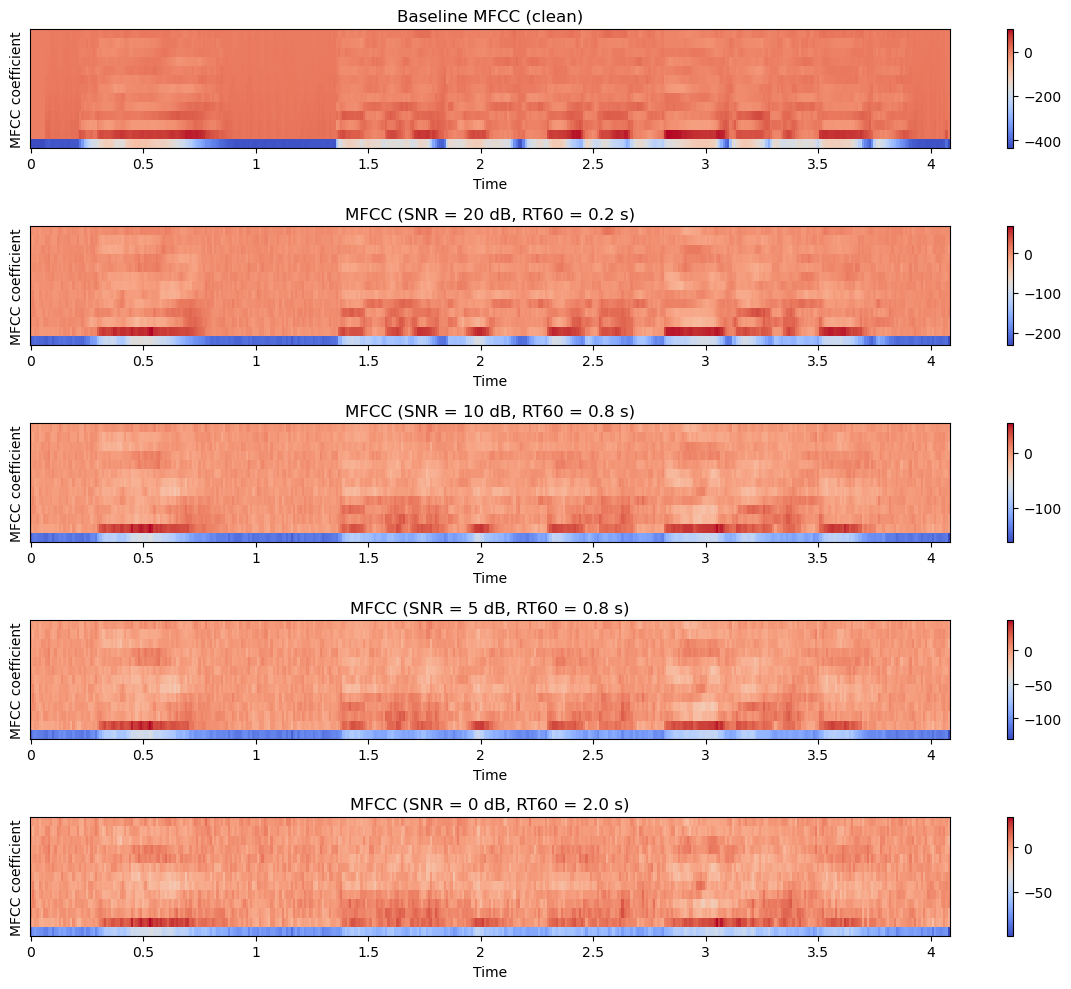

In [44]:
# ===============================
# Plot MFCCs
# ===============================

plt.figure(figsize=(12, 10))

plt.subplot(len(combined_conditions) + 1, 1, 1)
librosa.display.specshow(
    mfcc_clean,
    sr=sr,
    hop_length=160,
    x_axis="time"
)
plt.title("Baseline MFCC (clean)")
plt.ylabel("MFCC coefficient")
plt.colorbar()

for i, (snr_db, rt60) in enumerate(combined_conditions, start=2):
    plt.subplot(len(combined_conditions) + 1, 1, i)
    librosa.display.specshow(
        mfcc_combined[(snr_db, rt60)],
        sr=sr,
        hop_length=160,
        x_axis="time"
    )
    plt.title(f"MFCC (SNR = {snr_db} dB, RT60 = {rt60} s)")
    plt.ylabel("MFCC coefficient")
    plt.colorbar()

plt.tight_layout()
plt.show()

## Compare combined distorted features with the clean baseline

We reuse the same evaluation metrics:

- Pearson correlation
- Spearman correlation
- Mean squared error (MSE)
- Cosine similarity

In [45]:
# ===============================
# Evaluate log-Mel under combined distortions
# ===============================

results_logmel_combined = {}

for cond in combined_conditions:
    results_logmel_combined[cond] = compute_metrics(
        logmel_clean,
        logmel_combined[cond]
    )

results_logmel_combined

{(20, 0.2): {'pearson_r': np.float32(0.84526664),
  'spearman_rho': np.float64(0.8948119180763694),
  'mse': 302.5328369140625,
  'cosine_similarity': np.float32(0.9713324)},
 (10, 0.8): {'pearson_r': np.float32(0.68703103),
  'spearman_rho': np.float64(0.7017383795600138),
  'mse': 584.7281494140625,
  'cosine_similarity': np.float32(0.9531836)},
 (5, 0.8): {'pearson_r': np.float32(0.5970732),
  'spearman_rho': np.float64(0.5674417653541307),
  'mse': 749.4146728515625,
  'cosine_similarity': np.float32(0.94439626)},
 (0, 2.0): {'pearson_r': np.float32(0.4625459),
  'spearman_rho': np.float64(0.4113575952338296),
  'mse': 1026.5679931640625,
  'cosine_similarity': np.float32(0.93416864)}}

## Evaluate MFCC under combined distortions

In [46]:
# ===============================
# Evaluate MFCC under combined distortions
# ===============================

results_mfcc_combined = {}

for cond in combined_conditions:
    results_mfcc_combined[cond] = compute_metrics(
        mfcc_clean,
        mfcc_combined[cond]
    )

results_mfcc_combined

{(20, 0.2): {'pearson_r': np.float32(0.96476996),
  'spearman_rho': np.float64(0.7908282456096131),
  'mse': 1136.2615966796875,
  'cosine_similarity': np.float32(0.9653908)},
 (10, 0.8): {'pearson_r': np.float32(0.9388276),
  'spearman_rho': np.float64(0.6386574543731932),
  'mse': 2207.139404296875,
  'cosine_similarity': np.float32(0.9402815)},
 (5, 0.8): {'pearson_r': np.float32(0.9250323),
  'spearman_rho': np.float64(0.5825067154839426),
  'mse': 2798.109375,
  'cosine_similarity': np.float32(0.9268258)},
 (0, 2.0): {'pearson_r': np.float32(0.9019292),
  'spearman_rho': np.float64(0.4800162732168486),
  'mse': 3622.255126953125,
  'cosine_similarity': np.float32(0.9049165)}}

## Print combined-distortion results

In [47]:
# ===============================
# Print results
# ===============================

print("=== log-Mel robustness under combined distortions ===")
for snr_db, rt60 in combined_conditions:
    print(f"SNR = {snr_db} dB, RT60 = {rt60} s:", results_logmel_combined[(snr_db, rt60)])

print("\n=== MFCC robustness under combined distortions ===")
for snr_db, rt60 in combined_conditions:
    print(f"SNR = {snr_db} dB, RT60 = {rt60} s:", results_mfcc_combined[(snr_db, rt60)])

=== log-Mel robustness under combined distortions ===
SNR = 20 dB, RT60 = 0.2 s: {'pearson_r': np.float32(0.84526664), 'spearman_rho': np.float64(0.8948119180763694), 'mse': 302.5328369140625, 'cosine_similarity': np.float32(0.9713324)}
SNR = 10 dB, RT60 = 0.8 s: {'pearson_r': np.float32(0.68703103), 'spearman_rho': np.float64(0.7017383795600138), 'mse': 584.7281494140625, 'cosine_similarity': np.float32(0.9531836)}
SNR = 5 dB, RT60 = 0.8 s: {'pearson_r': np.float32(0.5970732), 'spearman_rho': np.float64(0.5674417653541307), 'mse': 749.4146728515625, 'cosine_similarity': np.float32(0.94439626)}
SNR = 0 dB, RT60 = 2.0 s: {'pearson_r': np.float32(0.4625459), 'spearman_rho': np.float64(0.4113575952338296), 'mse': 1026.5679931640625, 'cosine_similarity': np.float32(0.93416864)}

=== MFCC robustness under combined distortions ===
SNR = 20 dB, RT60 = 0.2 s: {'pearson_r': np.float32(0.96476996), 'spearman_rho': np.float64(0.7908282456096131), 'mse': 1136.2615966796875, 'cosine_similarity': np

## Visualize Pearson correlation under combined distortions

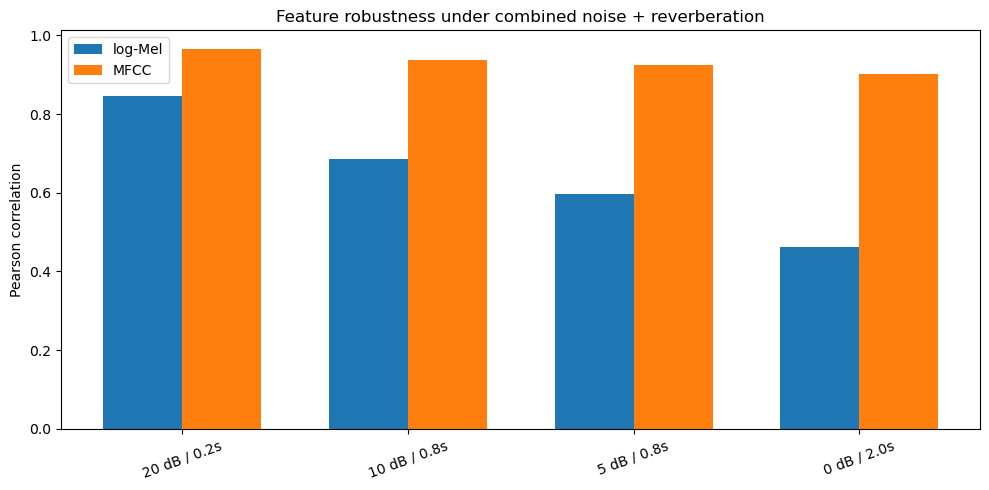

In [48]:
# ===============================
# Plot Pearson correlation for combined conditions
# ===============================

condition_labels = [f"{snr} dB / {rt60}s" for snr, rt60 in combined_conditions]

logmel_r_combined = [results_logmel_combined[c]["pearson_r"] for c in combined_conditions]
mfcc_r_combined = [results_mfcc_combined[c]["pearson_r"] for c in combined_conditions]

x = np.arange(len(combined_conditions))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, logmel_r_combined, width=width, label="log-Mel")
plt.bar(x + width/2, mfcc_r_combined, width=width, label="MFCC")

plt.xticks(x, condition_labels, rotation=20)
plt.ylabel("Pearson correlation")
plt.title("Feature robustness under combined noise + reverberation")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation

Combined distortions are expected to be more challenging than single distortions.

Typical trends include:

- lower correlation with the clean baseline
- larger MSE
- stronger degradation at low SNR and large RT60

This experiment shows how speech features behave in more realistic acoustic conditions.

# Summary of Robustness Experiments

We now summarize the results from:

Task 2 — Noise augmentation  
Task 3 — Reverberation  
Task 4 — Combined distortions

For each condition we report:

- Pearson correlation
- Spearman correlation
- Mean squared error
- Cosine similarity

These values quantify the similarity between distorted features and the clean baseline.

In [49]:
import pandas as pd

summary_rows = []

# Task 2: noise
for snr_db in snr_levels:
    r = results_logmel_noise[snr_db]
    summary_rows.append({
        "task": "noise",
        "condition": f"SNR={snr_db} dB",
        "pearson": r["pearson_r"],
        "spearman": r["spearman_rho"],
        "mse": r["mse"],
        "cosine": r["cosine_similarity"]
    })

# Task 3: reverberation
for rt60 in rt60_levels:
    r = results_logmel_reverb[rt60]
    summary_rows.append({
        "task": "reverb",
        "condition": f"RT60={rt60}",
        "pearson": r["pearson_r"],
        "spearman": r["spearman_rho"],
        "mse": r["mse"],
        "cosine": r["cosine_similarity"]
    })

# Task 4: combined
for snr_db, rt60 in combined_conditions:
    r = results_logmel_combined[(snr_db, rt60)]
    summary_rows.append({
        "task": "combined",
        "condition": f"SNR={snr_db},RT60={rt60}",
        "pearson": r["pearson_r"],
        "spearman": r["spearman_rho"],
        "mse": r["mse"],
        "cosine": r["cosine_similarity"]
    })

summary_table = pd.DataFrame(summary_rows)

summary_table

,task,condition,pearson,spearman,mse,cosine
0,noise,SNR=20 dB,0.853231,0.904518,318.724060,0.973441
1,noise,SNR=10 dB,0.710374,0.714953,594.675476,0.955704
2,noise,SNR=5 dB,0.617816,0.570578,782.764893,0.946614
3,noise,SNR=0 dB,0.511722,0.430322,1003.918335,0.937764
4,reverb,RT60=0.2,0.976127,0.974512,22.275919,0.996157
5,reverb,RT60=0.8,0.903893,0.906435,100.632217,0.984626
6,reverb,RT60=2.0,0.738140,0.752940,322.657135,0.958462
7,combined,"SNR=20,RT60=0.2",0.845267,0.894812,302.532837,0.971332
8,combined,"SNR=10,RT60=0.8",0.687031,0.701738,584.728149,0.953184
9,combined,"SNR=5,RT60=0.8",0.597073,0.567442,749.414673,0.944396


# Final Comparison of Feature Robustness

We visualize how feature similarity changes under different acoustic distortions.

The plots compare:

- noise
- reverberation
- combined distortions

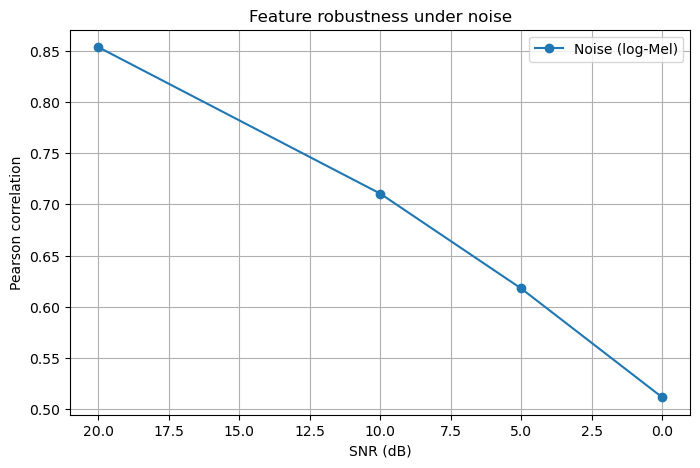

In [50]:
plt.figure(figsize=(8,5))

# Noise curve
snr_plot = snr_levels
noise_r = [results_logmel_noise[s]["pearson_r"] for s in snr_plot]

plt.plot(snr_plot, noise_r, marker="o", label="Noise (log-Mel)")

plt.gca().invert_xaxis()

plt.xlabel("SNR (dB)")
plt.ylabel("Pearson correlation")
plt.title("Feature robustness under noise")
plt.grid(True)
plt.legend()

plt.show()

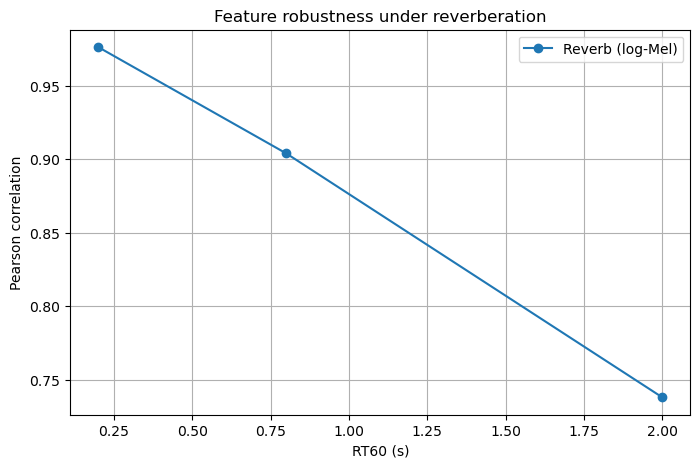

In [51]:
plt.figure(figsize=(8,5))

rt60_plot = rt60_levels
reverb_r = [results_logmel_reverb[r]["pearson_r"] for r in rt60_plot]

plt.plot(rt60_plot, reverb_r, marker="o", label="Reverb (log-Mel)")

plt.xlabel("RT60 (s)")
plt.ylabel("Pearson correlation")
plt.title("Feature robustness under reverberation")
plt.grid(True)
plt.legend()

plt.show()

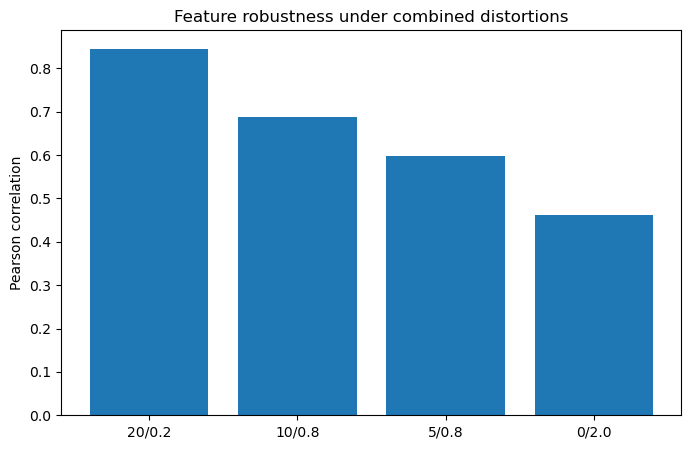

In [52]:
plt.figure(figsize=(8,5))

labels = [f"{snr}/{rt}" for snr,rt in combined_conditions]
vals = [results_logmel_combined[c]["pearson_r"] for c in combined_conditions]

plt.bar(labels, vals)

plt.ylabel("Pearson correlation")
plt.title("Feature robustness under combined distortions")

plt.show()

# Short Report — Feature Robustness Experiment

## 1. Objective

The goal of this experiment is to evaluate the robustness of speech features under realistic acoustic distortions.

We analyze two feature representations:

- log-Mel spectrogram
- MFCC

The experiments consider three types of distortions:

- additive noise
- reverberation
- combined noise and reverberation

---

## 2. Experimental Setup

Audio signals were sampled at:

f_s = 16000 Hz

Feature extraction parameters:

- frame length ≈ 25 ms
- hop size ≈ 10 ms
- n_mels = 40

Evaluation metrics:

- Pearson correlation
- Spearman correlation
- mean squared error
- cosine similarity

---

## 3. Results

### Noise experiment

Describe how feature similarity changes as SNR decreases.

### Reverberation experiment

Describe how feature similarity changes as RT60 increases.

### Combined distortions

Discuss how noise and reverberation together affect feature stability.

---

## 4. Discussion

Typical observations may include:

- correlation decreases as distortion increases
- MSE increases with stronger distortion
- MFCC features may remain relatively stable under mild noise

Explain which features appear more robust and why.

---

## 5. Conclusion

Summarize the main findings about feature robustness and how they relate to real-world speech recognition systems.